In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
# para normalização - MinMaxScaler
# para padronização normal - StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold,  cross_validate
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, accuracy_score, precision_score, recall_score, f1_score,roc_curve, roc_auc_score

from plot_aux import plot_boxplots_by_columns, plot_by_columns, plot_boxplots_by_columns_hue, plot_bar_list_features
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.exceptions import ConvergenceWarning


warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning, module='sklearn.svm')

In [2]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [4]:
df['blood_glucose_level'] = df['blood_glucose_level'].astype(float)

In [5]:
def plot_confusion_matrix(y_test, y_pred):

  conf_matrix = confusion_matrix(y_test, y_pred)

  sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
  plt.title('Matriz de Confusão')
  plt.xlabel('Predito')
  plt.ylabel('Verdadeiro')
  plt.show()
  

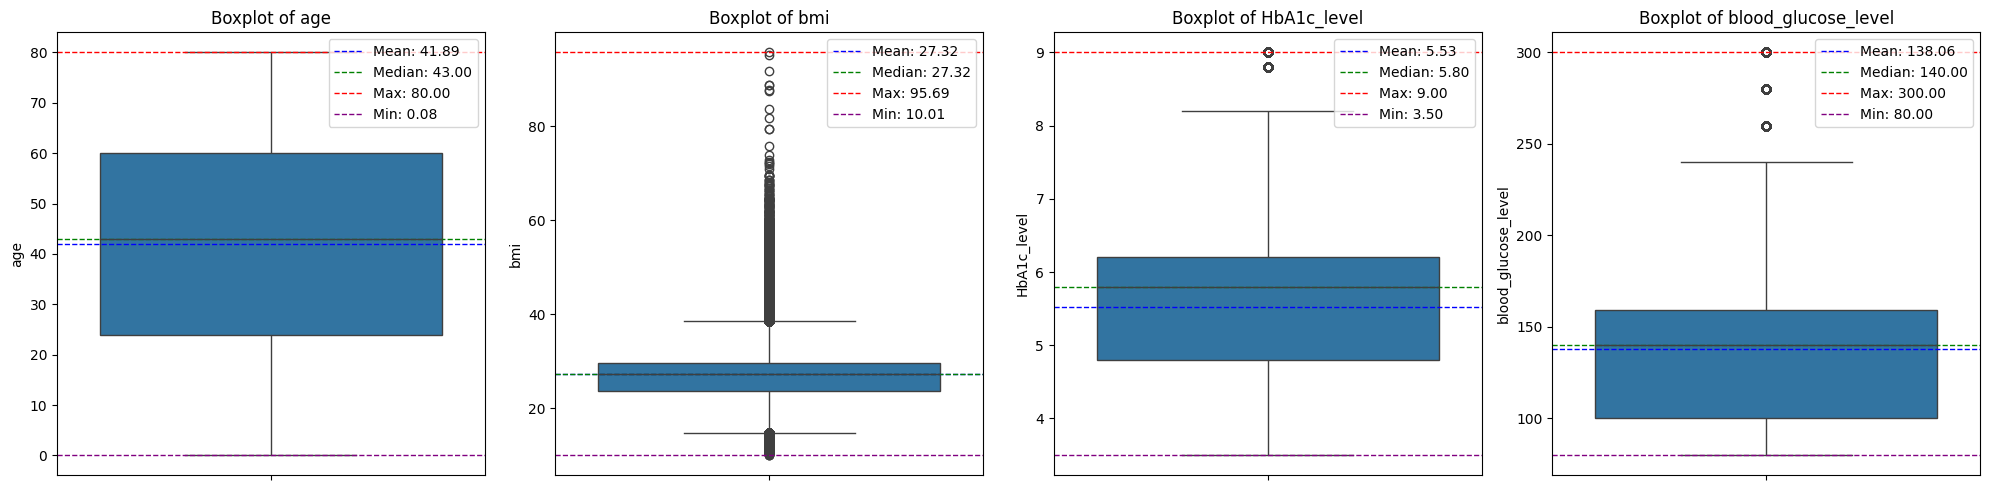

In [6]:
features_list = df.select_dtypes("float").columns.tolist()
plot_boxplots_by_columns(df,features_list)

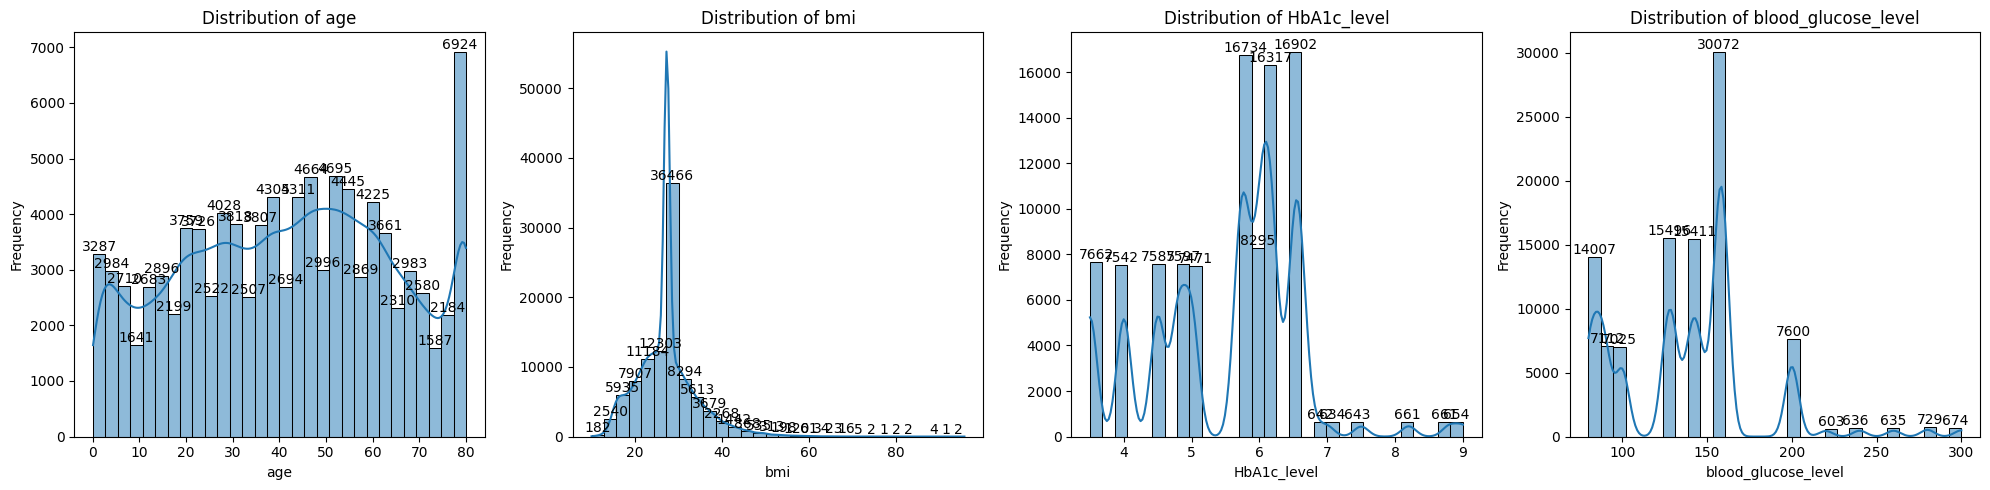

In [7]:
plot_by_columns(df,features_list)

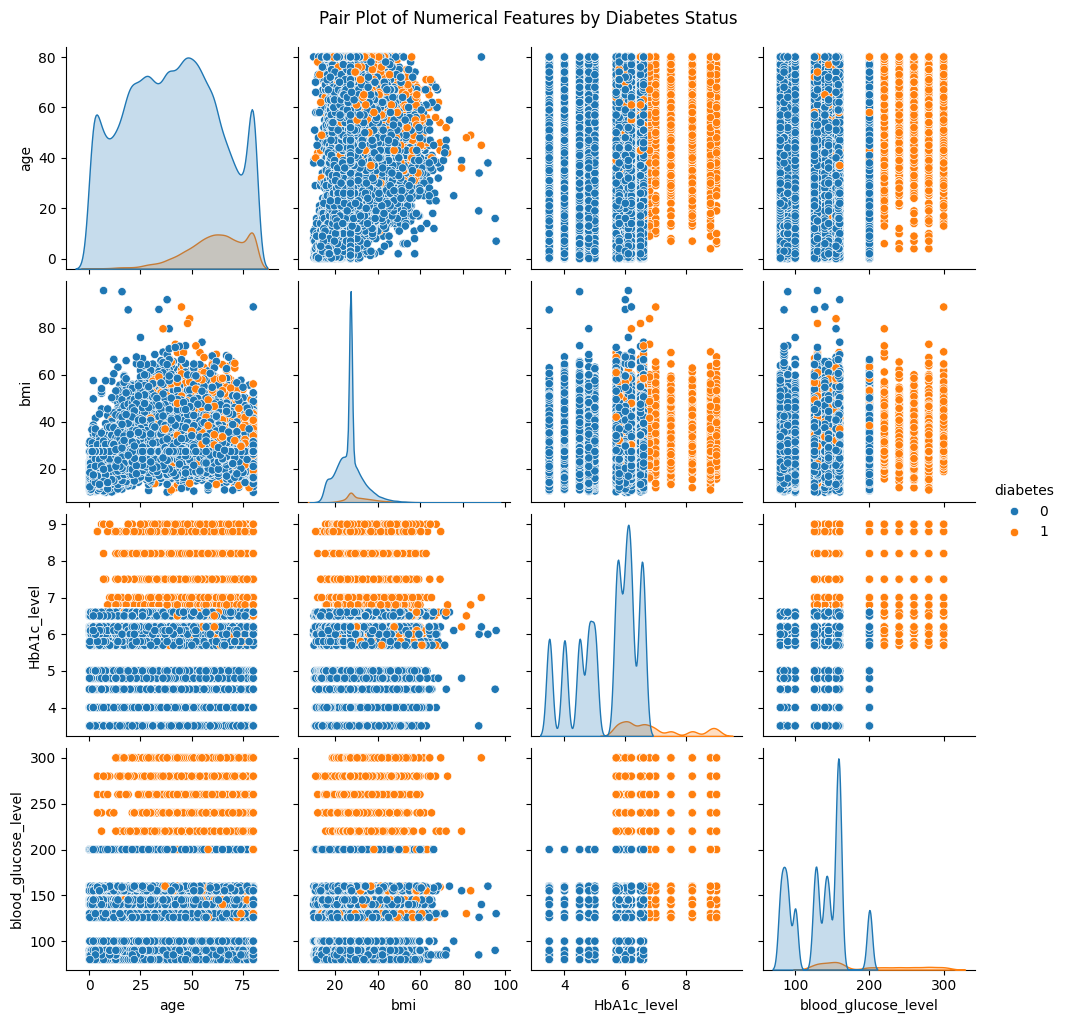

In [8]:
sns.pairplot(df[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']], hue='diabetes')
plt.suptitle('Pair Plot of Numerical Features by Diabetes Status', y=1.02) # Adjust title position
plt.show()

In [11]:
string_features =  df.select_dtypes("object").columns.tolist()
string_features_bool = df.select_dtypes("bool").columns.tolist()
# string_features.remove('name')

In [ ]:
def plot_bar_list_features(df:pd.DataFrame, feature_list:List[str]):
    fig, axes = plt.subplots(4, 2, figsize=(15, 5 * 3))
    fig.suptitle('TOP 10 : Quantidade de heróis por features', fontsize=14)

    axes = axes.flatten()
    for i, column in enumerate(feature_list):

        hero_counts = df.groupby(f'{column}').count()['name'].sort_values(ascending=False).reset_index(name='hero_count')[0:10]
        hero_counts[f'{column}'] = hero_counts[f'{column}'].astype(str)
        # colors = hero_counts[f'{column}'].map({'False': 'lightgreen', 'True': 'green'})
        bars = axes[i].bar(hero_counts[f'{column}'], hero_counts['hero_count'], color='green')
        for bar in bars:
            yval = bar.get_height()
            axes[i].text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom')

        axes[i].set_title(f'{column}', fontsize=12)
        # axes[i].set_xlabel('Cluster', fontsize=10)
        # axes[i].set_ylabel(column, fontsize=10)
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_ylim(0, max(hero_counts['hero_count']) + 100)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

KeyError: 'name'

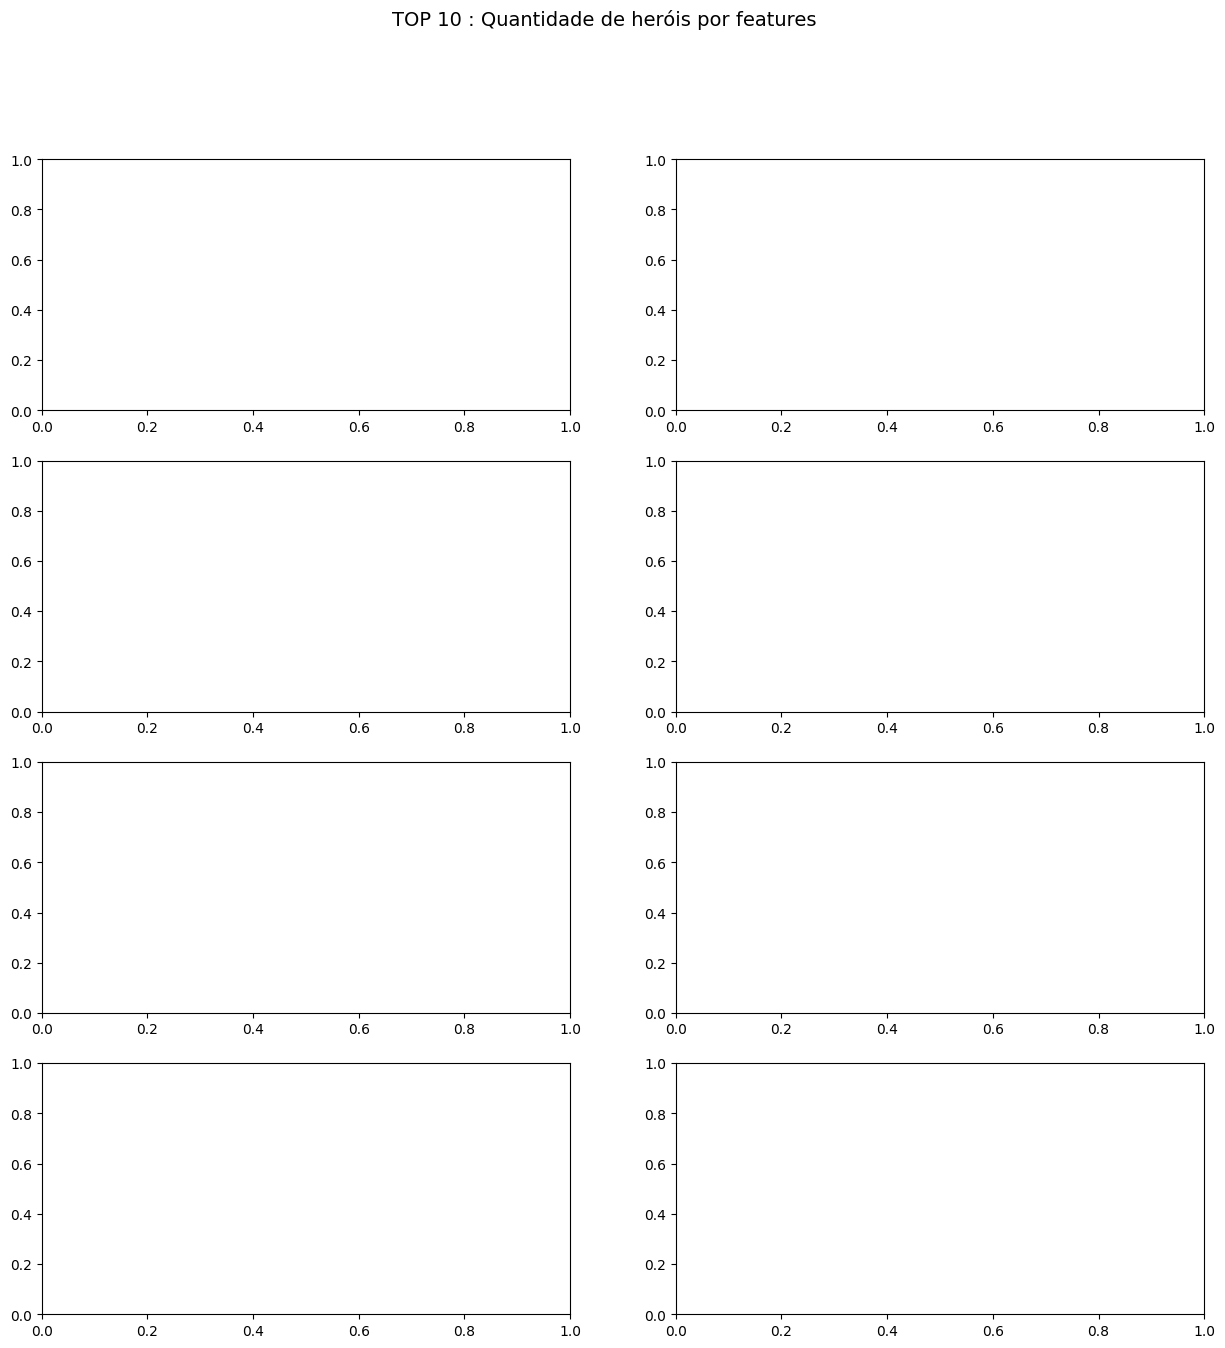

In [13]:
plot_bar_list_features(df=df, feature_list = string_features)

In [ ]:
plot_bar_list_features(df=df, feature_list = string_features_bool[0:8])

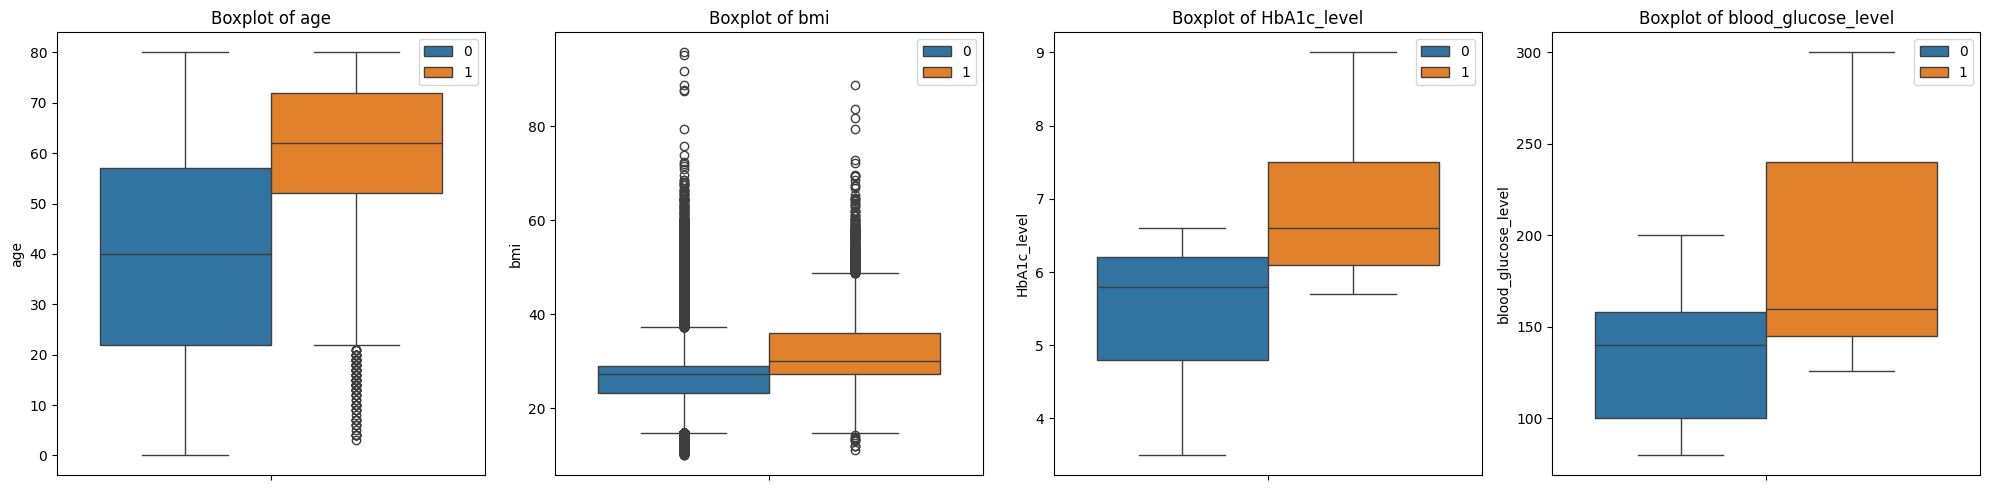

In [17]:
plot_boxplots_by_columns_hue(df=df, column_names=['age', 'bmi', 'HbA1c_level', 'blood_glucose_level'], hue='diabetes')